# Physics-Informed DeepONet for Two-Dimensional Linear Elasticity

The PDE here is **2D static linear elasticity**, not diffusion.

We learn the operator

$$
\mathcal{G}: \mathbf{f}(x,y) \longmapsto \mathbf{u}(x,y),
$$

where $\mathbf{f}=(f_x,f_y)$ is a body-force field and $\mathbf{u}=(u_x,u_y)$ is the displacement field.

The governing PDE is the Navier--Cauchy equation:

$$
\mu \nabla^2 \mathbf{u} + (\lambda+\mu)\nabla(\nabla\cdot\mathbf{u}) + \mathbf{f}=\mathbf{0},
\qquad (x,y)\in\Omega=[0,1]^2.
$$

Boundary condition:

$$
\mathbf{u}=\mathbf{0}\quad\text{on }\partial\Omega.
$$

This notebook is self-contained: it generates data, trains the PIDeepONet, saves the best model, plots loss/error, predicts displacement, and computes stress fields.

In [1]:
# ==========================================================
# 0. Imports, reproducibility, and device setup
# ==========================================================
import os
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def setup_seed(seed=1234):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

setup_seed(1234)

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

dtype = torch.float32
print("Using device:", device)

Using device: mps


## 1. Physics

For small-strain isotropic elasticity,

$$
\boldsymbol{\varepsilon}=\frac{1}{2}\left(\nabla\mathbf{u}+\nabla\mathbf{u}^{T}\right),
$$

$$
\boldsymbol{\sigma}=\lambda \operatorname{tr}(\boldsymbol{\varepsilon})\mathbf{I}+2\mu\boldsymbol{\varepsilon},
$$

and static equilibrium is

$$
\nabla\cdot\boldsymbol{\sigma}+\mathbf{f}=\mathbf{0}.
$$

For constant Lamé parameters, this gives

$$
\mu \nabla^2 \mathbf{u}+(\lambda+\mu)\nabla(\nabla\cdot\mathbf{u})+\mathbf{f}=\mathbf{0}.
$$

In [2]:
# ==========================================================
# 1. Problem parameters
# ==========================================================
res = 29
h = 1.0 / (res - 1)

# Nondimensional plane-strain elastic constants.
E0 = 1.0
nu = 0.30
lam = E0 * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu  = E0 / (2.0 * (1.0 + nu))

print(f"lambda = {lam:.6f}, mu = {mu:.6f}, h = {h:.6f}")

x1d = torch.linspace(0.0, 1.0, res, dtype=dtype)
y1d = torch.linspace(0.0, 1.0, res, dtype=dtype)
Y, X = torch.meshgrid(y1d, x1d, indexing="ij")
grid = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)
print("grid shape:", grid.shape)

lambda = 0.576923, mu = 0.384615, h = 0.035714
grid shape: torch.Size([841, 2])


## 2. Training Data

The training data are generated using a manufactured solution. Each displacement field is a random sum of sine modes:

$$
u_x(x,y)=\sum_k a_k\sin(p_k\pi x)\sin(q_k\pi y),
$$

$$
u_y(x,y)=\sum_k b_k\sin(p_k\pi x)\sin(q_k\pi y).
$$

These functions satisfy

$$
\mathbf{u}=\mathbf{0}\quad\text{on }\partial\Omega
$$

exactly. The corresponding body force is computed from

$$
\mathbf{f}=-\left[\mu\nabla^2\mathbf{u}+(\lambda+\mu)\nabla(\nabla\cdot\mathbf{u})\right].
$$

Therefore, every generated sample satisfies the discrete elasticity equation.

In [4]:
# ==========================================================
# 2. Finite-difference elasticity operator and data generator
# ==========================================================
def elasticity_operator_fd(u, lam, mu, h):
    """
    Computes L(u) = mu*laplacian(u) + (lambda+mu)*grad(div(u))
    with second-order finite differences.

    u shape: [B, res, res, 2]
    output shape: [B, res-2, res-2, 2]
    """
    ux = u[..., 0:1]
    uy = u[..., 1:2]

    ux_xx = (ux[:, 1:-1, 2:, :] - 2.0 * ux[:, 1:-1, 1:-1, :] + ux[:, 1:-1, :-2, :]) / h**2
    ux_yy = (ux[:, 2:, 1:-1, :] - 2.0 * ux[:, 1:-1, 1:-1, :] + ux[:, :-2, 1:-1, :]) / h**2
    uy_xx = (uy[:, 1:-1, 2:, :] - 2.0 * uy[:, 1:-1, 1:-1, :] + uy[:, 1:-1, :-2, :]) / h**2
    uy_yy = (uy[:, 2:, 1:-1, :] - 2.0 * uy[:, 1:-1, 1:-1, :] + uy[:, :-2, 1:-1, :]) / h**2

    ux_xy = (ux[:, 2:, 2:, :] - ux[:, 2:, :-2, :] - ux[:, :-2, 2:, :] + ux[:, :-2, :-2, :]) / (4.0 * h**2)
    uy_xy = (uy[:, 2:, 2:, :] - uy[:, 2:, :-2, :] - uy[:, :-2, 2:, :] + uy[:, :-2, :-2, :]) / (4.0 * h**2)

    Lx = mu * (ux_xx + ux_yy) + (lam + mu) * (ux_xx + uy_xy)
    Ly = mu * (uy_xx + uy_yy) + (lam + mu) * (ux_xy + uy_yy)
    return torch.cat([Lx, Ly], dim=-1)


modes = [(1,1), (1,2), (2,1), (2,2), (1,3), (3,1)]
num_modes = len(modes)


def sine_features(x, modes):
    """Fixed trunk basis: sin(p*pi*x) sin(q*pi*y)."""
    xx = x[..., 0:1]
    yy = x[..., 1:2]
    feats = []
    for p, q in modes:
        feats.append(torch.sin(p * math.pi * xx) * torch.sin(q * math.pi * yy))
    return torch.cat(feats, dim=-1)


def make_elasticity_dataset(n_samples, res=29, amp=0.04, seed=0):
    g = torch.Generator().manual_seed(seed)
    x1 = torch.linspace(0.0, 1.0, res, dtype=dtype)
    y1 = torch.linspace(0.0, 1.0, res, dtype=dtype)
    YY, XX = torch.meshgrid(y1, x1, indexing="ij")

    u_all = torch.zeros(n_samples, res, res, 2, dtype=dtype)
    coeff_all = torch.zeros(n_samples, 2 * num_modes, dtype=dtype)

    for s in range(n_samples):
        ux = torch.zeros(res, res, dtype=dtype)
        uy = torch.zeros(res, res, dtype=dtype)
        coeff_x = []
        coeff_y = []
        for (p, q) in modes:
            ax = amp * torch.randn((), generator=g)
            ay = amp * torch.randn((), generator=g)
            basis = torch.sin(p * math.pi * XX) * torch.sin(q * math.pi * YY)
            ux = ux + ax * basis
            uy = uy + ay * basis
            coeff_x.append(ax)
            coeff_y.append(ay)
        u_all[s, ..., 0] = ux
        u_all[s, ..., 1] = uy
        coeff_all[s, :num_modes] = torch.stack(coeff_x)
        coeff_all[s, num_modes:] = torch.stack(coeff_y)

    Lu_int = elasticity_operator_fd(u_all, lam, mu, h)
    f_all = torch.zeros_like(u_all)
    f_all[:, 1:-1, 1:-1, :] = -Lu_int

    grid_single = torch.stack([XX.reshape(-1), YY.reshape(-1)], dim=-1)
    x_all = grid_single.unsqueeze(0).repeat(n_samples, 1, 1)

    return f_all.reshape(n_samples, -1, 2), u_all.reshape(n_samples, -1, 2), x_all, coeff_all

n_train = 300
n_test = 60

f_train, u_train, x_train, coeff_train = make_elasticity_dataset(n_train, res=res, amp=0.04, seed=42)
f_test,  u_test,  x_test,  coeff_test  = make_elasticity_dataset(n_test,  res=res, amp=0.04, seed=999)

print("f_train:", f_train.shape)
print("u_train:", u_train.shape)
print("x_train:", x_train.shape)
print("f_test :", f_test.shape)
print("u_test :", u_test.shape)
print("x_test :", x_test.shape)

f_train: torch.Size([300, 841, 2])
u_train: torch.Size([300, 841, 2])
x_train: torch.Size([300, 841, 2])
f_test : torch.Size([60, 841, 2])
u_test : torch.Size([60, 841, 2])
x_test : torch.Size([60, 841, 2])


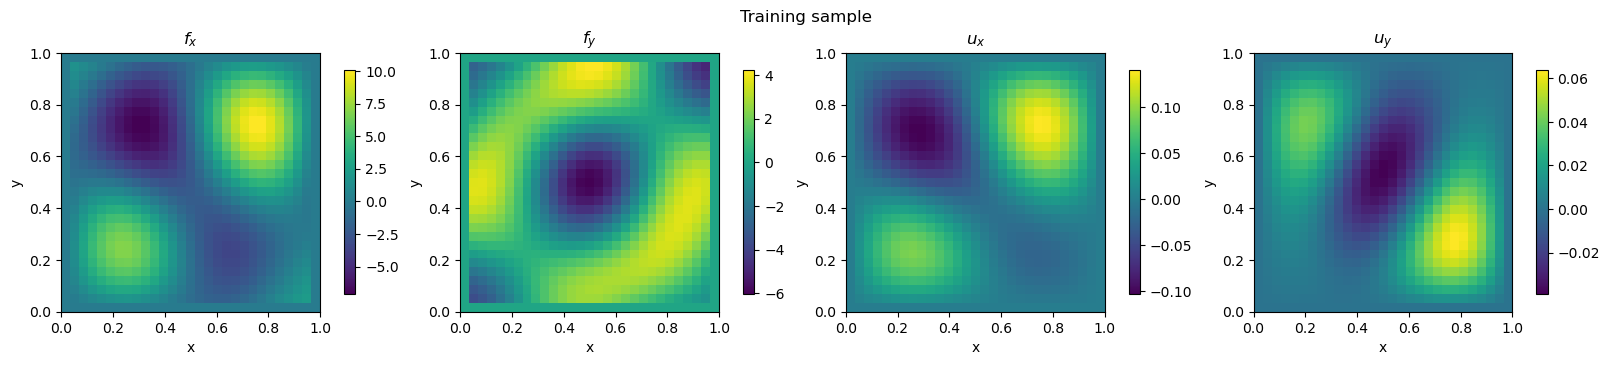

In [5]:
# ==========================================================
# 3. Visualize one generated sample
# ==========================================================
def plot_field_pair(f, u, sample_id=0, title_prefix="Training sample"):
    f0 = f[sample_id].reshape(res, res, 2).detach().cpu()
    u0 = u[sample_id].reshape(res, res, 2).detach().cpu()
    fig, axs = plt.subplots(1, 4, figsize=(16, 3.5), constrained_layout=True)
    fields = [f0[...,0], f0[...,1], u0[...,0], u0[...,1]]
    titles = [r"$f_x$", r"$f_y$", r"$u_x$", r"$u_y$"]
    for ax, field, title in zip(axs, fields, titles):
        im = ax.imshow(field, origin="lower", extent=[0,1,0,1], aspect="equal")
        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        fig.colorbar(im, ax=ax, shrink=0.8)
    fig.suptitle(title_prefix)
    plt.show()

plot_field_pair(f_train, u_train, sample_id=0)

## 3. PIDeepONet Architecture

The branch network takes the full force field $\mathbf{f}(x,y)$ and encodes it through sensor projections onto the same sine basis used by the trunk network.

The trunk network uses fixed sine basis functions:

$$
\phi_k(x,y)=\sin(p_k\pi x)\sin(q_k\pi y).
$$

This is still a DeepONet representation:

$$
u_x(x,y)=\sum_k b_{x,k}(\mathbf{f})\phi_k(x,y),
$$

$$
u_y(x,y)=\sum_k b_{y,k}(\mathbf{f})\phi_k(x,y).
$$

Because the trunk basis vanishes on the boundary, the zero-displacement boundary condition is satisfied exactly without adding a boundary-loss term.

In [6]:
# ==========================================================
# 4. DeepONet model
# ==========================================================
class BranchNet(nn.Module):
    def __init__(self, grid, hidden=64, out_dim=2*num_modes):
        super().__init__()
        # Sensor-projection features: integral-like projections of f_x and f_y onto the trunk basis.
        # This is a compact branch encoding of the input function f(x,y).
        phi_grid = sine_features(grid.unsqueeze(0), modes).squeeze(0)  # [N, num_modes]
        self.register_buffer("phi_grid", phi_grid)
        self.net = nn.Sequential(
            nn.Linear(2 * num_modes, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, f):
        # f shape: [B, N, 2]
        fx = f[..., 0]
        fy = f[..., 1]
        # Mean approximates an integral over sensor locations.
        feat_x = torch.einsum("bn,nm->bm", fx, self.phi_grid) / self.phi_grid.shape[0]
        feat_y = torch.einsum("bn,nm->bm", fy, self.phi_grid) / self.phi_grid.shape[0]
        features = torch.cat([feat_x, feat_y], dim=-1)
        return self.net(features)


class ElasticityPIDeepONet(nn.Module):
    def __init__(self, grid):
        super().__init__()
        self.branch = BranchNet(grid=grid, hidden=64, out_dim=2*num_modes)

    def forward(self, x, f):
        coeff = self.branch(f)                 # [B, 2*num_modes]
        coeff_x = coeff[:, :num_modes]
        coeff_y = coeff[:, num_modes:]
        phi = sine_features(x, modes)          # [B, N, num_modes]
        ux = torch.sum(coeff_x.unsqueeze(1) * phi, dim=-1, keepdim=True)
        uy = torch.sum(coeff_y.unsqueeze(1) * phi, dim=-1, keepdim=True)
        return torch.cat([ux, uy], dim=-1)


model = ElasticityPIDeepONet(grid=grid).to(device=device, dtype=dtype)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

Trainable parameters: 5,772


In [7]:
# ==========================================================
# 5. Loss functions
# ==========================================================
def relative_l2_error(pred, true, eps=1e-12):
    num = torch.linalg.norm((pred - true).reshape(pred.shape[0], -1), dim=1)
    den = torch.linalg.norm(true.reshape(true.shape[0], -1), dim=1) + eps
    return torch.mean(num / den)


def pde_loss(model, x_batch, f_batch):
    u = model(x_batch, f_batch).reshape(-1, res, res, 2)
    f_grid = f_batch.reshape(-1, res, res, 2)
    Lu_int = elasticity_operator_fd(u, lam, mu, h)
    f_int = f_grid[:, 1:-1, 1:-1, :]
    residual = Lu_int + f_int
    return torch.mean(residual**2)


def data_loss(model, x_batch, f_batch, u_batch):
    u_pred = model(x_batch, f_batch)
    return torch.mean((u_pred - u_batch)**2)

## 4. Training

The total training loss is

$$
\mathcal{L}=w_{data}\mathcal{L}_{data}+w_{PDE}\mathcal{L}_{PDE},
$$

where

$$
\mathcal{L}_{PDE}=\left\|\mu\nabla^2\mathbf{u}_{\theta}+(\lambda+\mu)\nabla(\nabla\cdot\mathbf{u}_{\theta})+\mathbf{f}\right\|_2^2.
$$

The data term teaches the operator from generated training pairs, while the PDE term enforces linear-elastic equilibrium.

In [8]:
# ==========================================================
# 6. Training loop
# ==========================================================
batch_size = 1
epochs = 500           # For quick debugging, set epochs=50. For final results, keep 500.
w_data = 1.0
w_pde = 1.0e-4

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=250, gamma=0.6)

f_train_d = f_train.to(device)
u_train_d = u_train.to(device)
x_train_d = x_train.to(device)
f_test_d  = f_test.to(device)
u_test_d  = u_test.to(device)
x_test_d  = x_test.to(device)

history = {"loss": [], "loss_data": [], "loss_pde": [], "test_l2": [], "time": [], "epoch": []}
best_error = float("inf")
best_state = None
start_time = time.time()

for epoch in range(1, epochs + 1):
    model.train()
    perm = torch.randperm(n_train, device=device)
    epoch_loss = 0.0
    epoch_data = 0.0
    epoch_pde = 0.0
    n_batches = 0

    for i in range(0, n_train, batch_size):
        idx = perm[i:i+batch_size]
        xb = x_train_d[idx]
        fb = f_train_d[idx]
        ub = u_train_d[idx]

        ld = data_loss(model, xb, fb, ub)
        lp = pde_loss(model, xb, fb)
        loss = w_data * ld + w_pde * lp

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_data += ld.item()
        epoch_pde += lp.item()
        n_batches += 1

    scheduler.step()

    if epoch % 10 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            preds = []
            for j in range(0, n_test, 1):
                preds.append(model(x_test_d[j:j+1], f_test_d[j:j+1]).cpu())
            u_pred_test = torch.cat(preds, dim=0).to(device)
            test_l2 = relative_l2_error(u_pred_test, u_test_d).item()

        history["epoch"].append(epoch)
        history["loss"].append(epoch_loss / n_batches)
        history["loss_data"].append(epoch_data / n_batches)
        history["loss_pde"].append(epoch_pde / n_batches)
        history["test_l2"].append(test_l2)
        history["time"].append(time.time() - start_time)

        if test_l2 < best_error:
            best_error = test_l2
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 50 == 0 or epoch == 1:
            lr = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch:4d} | loss={epoch_loss/n_batches:.3e} | "
                  f"data={epoch_data/n_batches:.3e} | pde={epoch_pde/n_batches:.3e} | "
                  f"test L2={test_l2:.4f} | lr={lr:.2e}")

print("Training finished.")
print(f"Best test relative L2 error: {best_error:.6f}")

os.makedirs("saved_models", exist_ok=True)
torch.save({
    "model_state_dict": best_state,
    "history": history,
    "res": res,
    "lambda": lam,
    "mu": mu,
    "nu": nu,
    "E0": E0,
    "modes": modes,
}, "saved_models/pideeponet_linear_elasticity_best.pt")
print("Saved model to saved_models/pideeponet_linear_elasticity_best.pt")

Epoch    1 | loss=1.623e-03 | data=1.265e-03 | pde=3.577e+00 | test L2=0.4489 | lr=1.00e-03
Epoch   50 | loss=2.457e-05 | data=1.764e-05 | pde=6.922e-02 | test L2=0.1166 | lr=1.00e-03
Epoch  100 | loss=1.526e-05 | data=1.048e-05 | pde=4.782e-02 | test L2=0.0568 | lr=1.00e-03
Epoch  150 | loss=9.102e-06 | data=6.772e-06 | pde=2.331e-02 | test L2=0.0592 | lr=1.00e-03
Epoch  200 | loss=1.456e-05 | data=9.690e-06 | pde=4.868e-02 | test L2=0.0714 | lr=1.00e-03
Epoch  250 | loss=1.581e-05 | data=1.084e-05 | pde=4.967e-02 | test L2=0.0786 | lr=6.00e-04
Epoch  300 | loss=5.593e-06 | data=4.063e-06 | pde=1.530e-02 | test L2=0.0309 | lr=6.00e-04
Epoch  350 | loss=6.333e-06 | data=5.193e-06 | pde=1.140e-02 | test L2=0.0544 | lr=6.00e-04
Epoch  400 | loss=4.729e-06 | data=3.650e-06 | pde=1.079e-02 | test L2=0.0527 | lr=6.00e-04
Epoch  450 | loss=3.694e-06 | data=2.354e-06 | pde=1.340e-02 | test L2=0.0315 | lr=6.00e-04
Epoch  500 | loss=3.007e-06 | data=2.178e-06 | pde=8.289e-03 | test L2=0.0341 | 

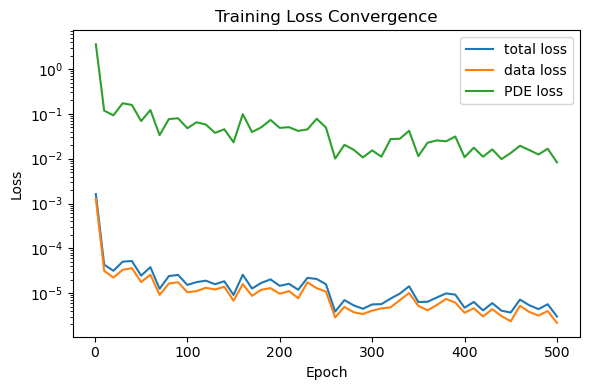

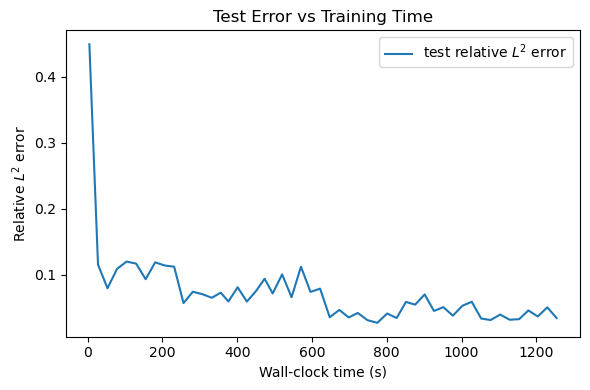

In [9]:
# ==========================================================
# 7. Plot training history
# ==========================================================
plt.figure(figsize=(6, 4))
plt.semilogy(history["epoch"], history["loss"], label="total loss")
plt.semilogy(history["epoch"], history["loss_data"], label="data loss")
plt.semilogy(history["epoch"], history["loss_pde"], label="PDE loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Convergence")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history["time"], history["test_l2"], label=r"test relative $L^2$ error")
plt.xlabel("Wall-clock time (s)")
plt.ylabel(r"Relative $L^2$ error")
plt.title("Test Error vs Training Time")
plt.legend()
plt.tight_layout()
plt.show()

Final loaded-model test relative L2 error: 0.026897


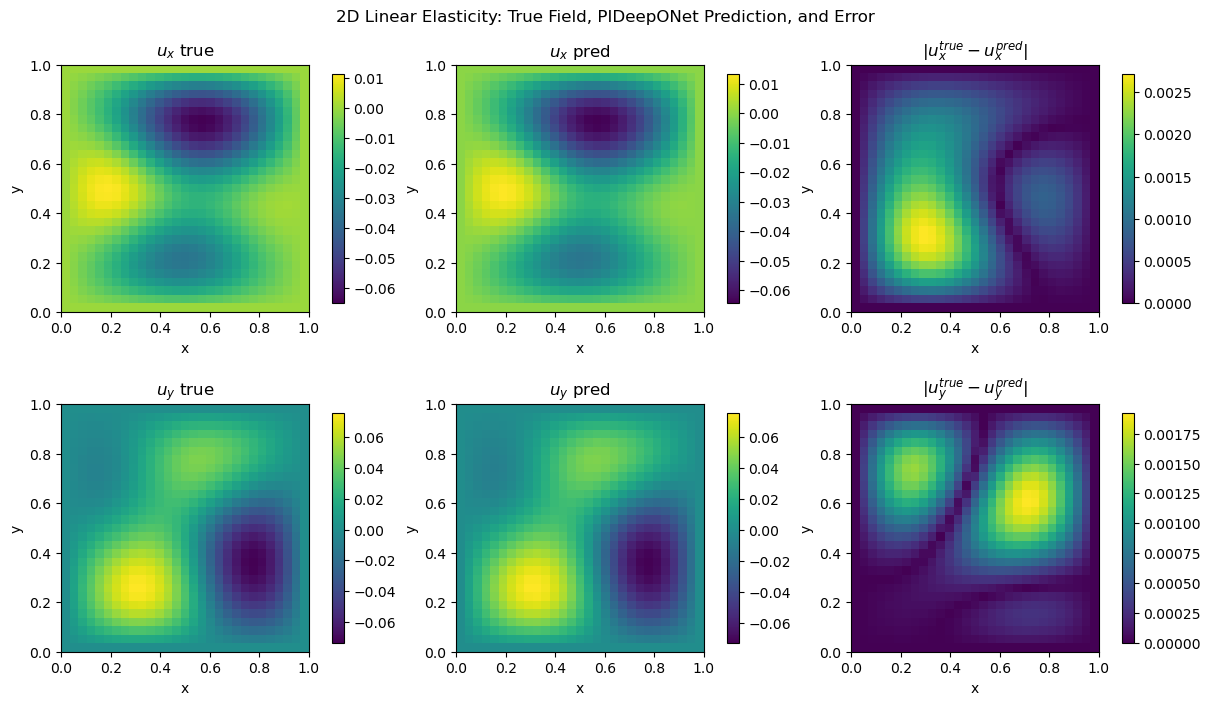

In [10]:
# ==========================================================
# 8. Load best model and visualize predictions
# ==========================================================
checkpoint = torch.load("saved_models/pideeponet_linear_elasticity_best.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

with torch.no_grad():
    preds = []
    for j in range(0, n_test, 1):
        preds.append(model(x_test_d[j:j+1], f_test_d[j:j+1]).cpu())
    u_pred = torch.cat(preds, dim=0)

test_l2_final = relative_l2_error(u_pred, u_test).item()
print(f"Final loaded-model test relative L2 error: {test_l2_final:.6f}")

sample_id = 0
up = u_pred[sample_id].reshape(res, res, 2)
ut = u_test[sample_id].reshape(res, res, 2)
err = torch.abs(up - ut)

fig, axs = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
fields = [ut[...,0], up[...,0], err[...,0], ut[...,1], up[...,1], err[...,1]]
titles = [r"$u_x$ true", r"$u_x$ pred", r"$|u_x^{true}-u_x^{pred}|$",
          r"$u_y$ true", r"$u_y$ pred", r"$|u_y^{true}-u_y^{pred}|$"]
for ax, field, title in zip(axs.ravel(), fields, titles):
    im = ax.imshow(field.detach().cpu(), origin="lower", extent=[0,1,0,1], aspect="equal")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("2D Linear Elasticity: True Field, PIDeepONet Prediction, and Error")
plt.show()

## 5. Stress Components

The stress components are computed from the predicted displacement using

$$
\varepsilon_{xx}=\frac{\partial u_x}{\partial x},\qquad
\varepsilon_{yy}=\frac{\partial u_y}{\partial y},\qquad
\varepsilon_{xy}=\frac{1}{2}\left(\frac{\partial u_x}{\partial y}+\frac{\partial u_y}{\partial x}\right),
$$

$$
\sigma_{xx}=(\lambda+2\mu)\varepsilon_{xx}+\lambda\varepsilon_{yy},
$$

$$
\sigma_{yy}=\lambda\varepsilon_{xx}+(\lambda+2\mu)\varepsilon_{yy},
$$

$$
\sigma_{xy}=2\mu\varepsilon_{xy}.
$$

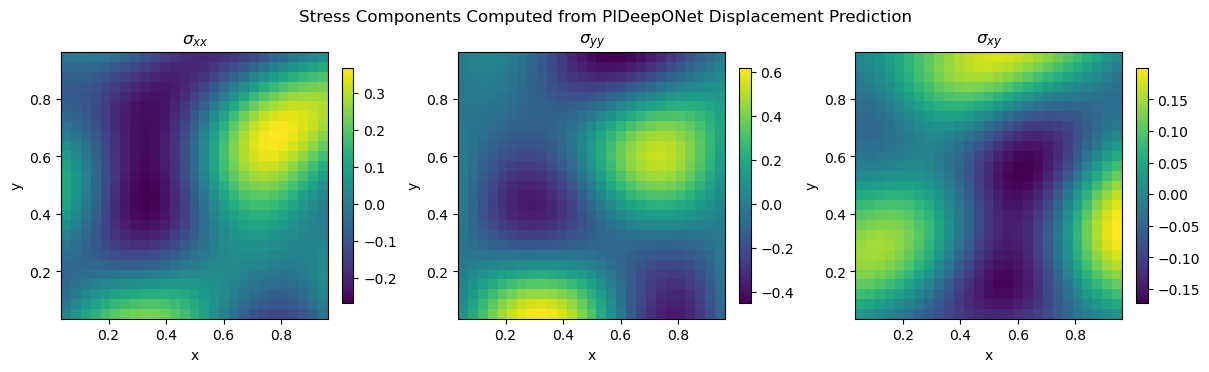

In [11]:
# ==========================================================
# 9. Compute and plot stress components from predicted displacement
# ==========================================================
def stress_from_displacement_fd(u_grid, lam, mu, h):
    ux = u_grid[..., 0:1].unsqueeze(0)
    uy = u_grid[..., 1:2].unsqueeze(0)

    ux_x = (ux[:, 1:-1, 2:, :] - ux[:, 1:-1, :-2, :]) / (2.0 * h)
    ux_y = (ux[:, 2:, 1:-1, :] - ux[:, :-2, 1:-1, :]) / (2.0 * h)
    uy_x = (uy[:, 1:-1, 2:, :] - uy[:, 1:-1, :-2, :]) / (2.0 * h)
    uy_y = (uy[:, 2:, 1:-1, :] - uy[:, :-2, 1:-1, :]) / (2.0 * h)

    eps_xx = ux_x
    eps_yy = uy_y
    eps_xy = 0.5 * (ux_y + uy_x)

    sig_xx = (lam + 2.0 * mu) * eps_xx + lam * eps_yy
    sig_yy = lam * eps_xx + (lam + 2.0 * mu) * eps_yy
    sig_xy = 2.0 * mu * eps_xy

    return sig_xx.squeeze(), sig_yy.squeeze(), sig_xy.squeeze()

sig_xx, sig_yy, sig_xy = stress_from_displacement_fd(up, lam, mu, h)

fig, axs = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
for ax, field, title in zip(axs, [sig_xx, sig_yy, sig_xy], [r"$\sigma_{xx}$", r"$\sigma_{yy}$", r"$\sigma_{xy}$"]):
    im = ax.imshow(field.detach().cpu(), origin="lower", extent=[h,1-h,h,1-h], aspect="equal")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Stress Components Computed from PIDeepONet Displacement Prediction")
plt.show()

## 6. Final Interpretation for Report

The PDE is the static Navier--Cauchy equation of 2D linear elasticity. The input function is the body-force field $\mathbf{f}(x,y)$, and the output function is the displacement field $\mathbf{u}(x,y)$.

The boundary condition $\mathbf{u}=\mathbf{0}$ on $\partial\Omega$ is satisfied exactly because the DeepONet trunk basis uses sine functions that vanish on all boundaries. The physics-informed residual enforces mechanical equilibrium:

$$
\mu\nabla^2\mathbf{u}_{\theta}+(\lambda+\mu)\nabla(\nabla\cdot\mathbf{u}_{\theta})+\mathbf{f}=\mathbf{0}.
$$

The required final-report outputs are generated by this notebook:

1. training loss convergence;
2. test relative $L^2$ error versus wall-clock time;
3. true displacement, predicted displacement, and error fields;
4. stress-field visualization computed from the predicted displacement.